# Test a Teachable Machine audio model (Background Noise / english / gujarati / hindi)
Put `model.json`, `weights.bin` and `metadata.json` in the same folder as this notebook (or upload them in Colab).
The `.tm` file is only the Teachable Machine project file and isn't needed here.

In [1]:
!pip install -q tensorflow librosa numpy matplotlib

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
statsmodels 0.14.6 requires packaging>=21.3, but you have packaging 20.9 which is incompatible.
ydata-profiling 4.18.1 requires matplotlib<=3.10,>=3.5, but you have matplotlib 3.11.0 which is incompatible.


In [2]:
import json, numpy as np, tensorflow as tf, librosa, matplotlib.pyplot as plt
from tensorflow.keras import layers, Model

MODEL_DIR = "."   # folder containing model.json, weights.bin, metadata.json
# Colab: uncomment to upload the 3 files
# from google.colab import files; files.upload()

meta = json.load(open(f"{MODEL_DIR}/metadata.json"))
LABELS = meta["wordLabels"]
manifest = json.load(open(f"{MODEL_DIR}/model.json"))["weightsManifest"][0]["weights"]
print(LABELS)

['Background Noise', 'english', 'gujarati', 'hindi']


## 1. Rebuild the network and load `weights.bin`

In [3]:
inp = layers.Input((43, 232, 1))
x = layers.Conv2D(8,  (2,8), activation="relu", name="conv2d_1")(inp)
x = layers.MaxPool2D((2,2), (2,2))(x)
x = layers.Conv2D(32, (2,4), activation="relu", name="conv2d_2")(x)
x = layers.MaxPool2D((2,2), (2,2))(x)
x = layers.Conv2D(32, (2,4), activation="relu", name="conv2d_3")(x)
x = layers.MaxPool2D((2,2), (2,2))(x)
x = layers.Conv2D(32, (2,4), activation="relu", name="conv2d_4")(x)
x = layers.MaxPool2D((2,2), (1,2))(x)
x = layers.Flatten()(x)
x = layers.Dense(2000, activation="relu", name="dense_1")(x)
out = layers.Dense(len(LABELS), activation="softmax", name="NewHeadDense")(x)
model = Model(inp, out)

raw = np.fromfile(f"{MODEL_DIR}/weights.bin", dtype="<f4")
W, pos = {}, 0
for w in manifest:
    n = int(np.prod(w["shape"]))
    W[w["name"]] = raw[pos:pos+n].reshape(w["shape"]); pos += n
assert pos == raw.size, "weights.bin size mismatch"

for name in ["conv2d_1","conv2d_2","conv2d_3","conv2d_4","dense_1","NewHeadDense"]:
    model.get_layer(name).set_weights([W[f"{name}/kernel"], W[f"{name}/bias"]])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 43, 232, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 42, 225, 8)     │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 21, 112, 8)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 109, 32)    │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 9, 51, 32)      │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 25, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 3, 22, 32)      │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 11, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 704)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2000)           │     1,410,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ NewHeadDense (Dense)            │ (None, 4)              │         8,004 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,436,668 (5.48 MB)

 Trainable params: 1,436,668 (5.48 MB)

 Non-trainable params: 0 (0.00 B)

## 2. Preprocessing (mimics the browser's speech-commands pipeline)
44.1 kHz audio, 1024-sample Blackman-windowed FFT, hop of 1024, dB magnitude, first 232 bins, 43 frames (~1 s), normalized by mean/std.
This is an approximation of WebAudio's analyser, so predictions can differ slightly from the Teachable Machine web preview.

In [4]:
SR, FFT, N_FRAMES, N_BINS = 44100, 1024, 43, 232
WIN = np.blackman(FFT)

def spectrogram(chunk):
    chunk = np.pad(chunk, (0, max(0, SR - len(chunk))))[:SR]
    frames = []
    for i in range(N_FRAMES):
        seg = chunk[i*FFT:(i+1)*FFT]
        seg = np.pad(seg, (0, FFT - len(seg)))
        mag = np.abs(np.fft.rfft(seg * WIN)) / FFT
        frames.append(20*np.log10(np.maximum(mag, 1e-10))[:N_BINS])
    s = np.array(frames, dtype=np.float32)
    return (s - s.mean()) / (s.std() + 1e-8)

def predict_chunk(chunk):
    s = spectrogram(chunk)
    p = model.predict(s[None, ..., None], verbose=0)[0]
    return p, s

def predict_file(path, hop=0.5, plot=True):
    y, _ = librosa.load(path, sr=SR, mono=True)
    starts = range(0, max(1, len(y) - SR + 1), int(hop*SR))
    probs = np.array([predict_chunk(y[s:s+SR])[0] for s in starts])
    mean = probs.mean(0)
    print(f"Windows: {len(probs)}")
    for l, p in zip(LABELS, mean): print(f"  {l:16s} {p*100:5.1f}%")
    print("=> Prediction:", LABELS[int(mean.argmax())])
    if plot:
        fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
        ax[0].imshow(predict_chunk(y[:SR])[1].T, origin="lower", aspect="auto"); ax[0].set_title("Spectrogram (first 1 s)")
        ax[1].plot(np.arange(len(probs))*hop, probs); ax[1].legend(LABELS); ax[1].set_title("Probability over time"); ax[1].set_xlabel("sec")
        plt.tight_layout(); plt.show()
    return mean

## 3. Test with an audio file (wav/mp3/m4a/ogg)

Windows: 8
  Background Noise  13.0%
  english           49.3%
  gujarati          10.7%
  hindi             27.0%
=> Prediction: english


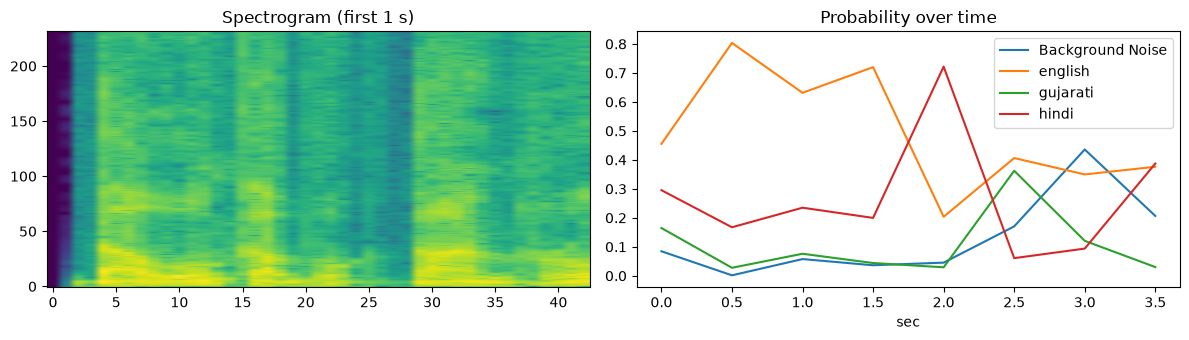

array([0.1297982 , 0.49321342, 0.10684825, 0.2701401 ], dtype=float32)

In [9]:
AUDIO = "42.mp3"   # change to your file
# Colab: from google.colab import files; AUDIO = list(files.upload())[0]
predict_file(AUDIO)

## 4. Record from your microphone — local Jupyter only
`pip install sounddevice`

Speak now...
Windows: 5
  Background Noise  32.1%
  english            8.4%
  gujarati          23.6%
  hindi             35.9%
=> Prediction: hindi


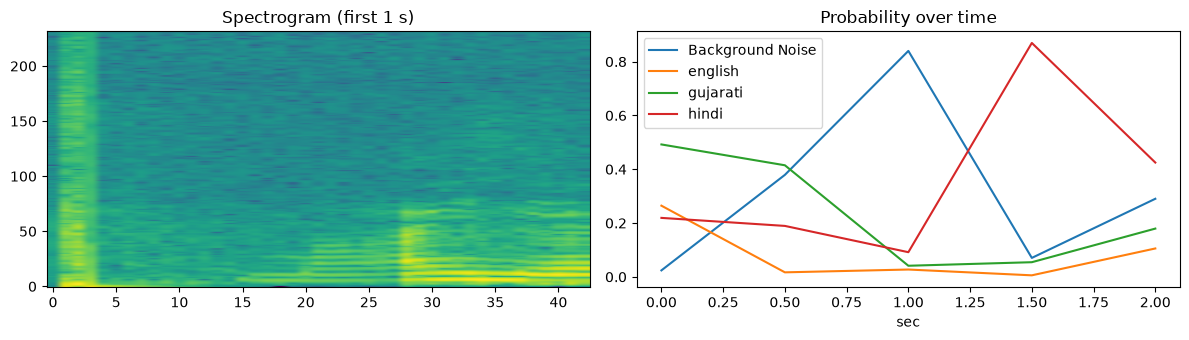

array([0.32074365, 0.08391693, 0.23640776, 0.3589317 ], dtype=float32)

In [8]:
import sounddevice as sd
print("Speak now..."); rec = sd.rec(SR*3, samplerate=SR, channels=1); sd.wait()
import soundfile as sf; sf.write("mic.wav", rec, SR)
predict_file("mic.wav")